# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

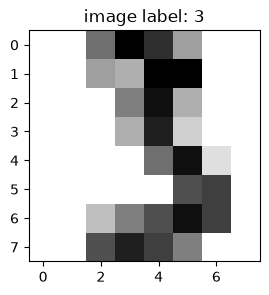

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [5]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [11]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [12]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [13]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.09, 0.91, 0]))

2.4079456086518722


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [14]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [15]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [16]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Linear combination of inputs and weights -> raw scores ("logits"),
        # shape (batch_size, output_size).
        Z = np.dot(X, self.W) + self.b
        # Softmax turns the logits into a probability distribution over classes
        # (each row is non-negative and sums to 1).
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Average negative log likelihood over the batch. nll() SUMS over samples,
        # so we divide by the number of samples to get a per-sample average.
        y_onehot = one_hot(self.output_size, y.astype(int))
        return nll(y_onehot, self.forward(X)) / X.shape[0]

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [17]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

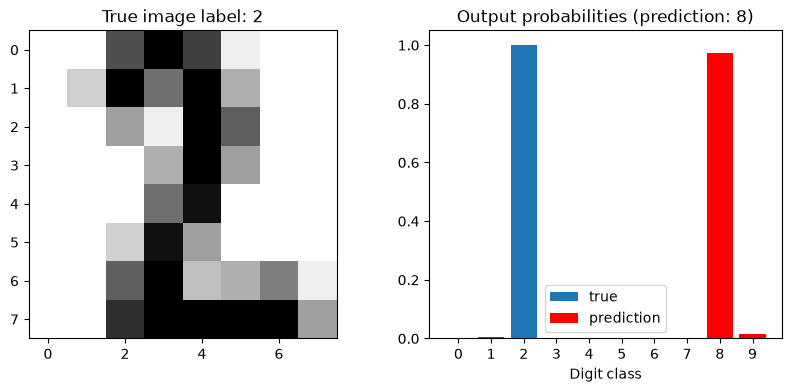

In [18]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [19]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 3
Average NLL over the last 100 samples at step 200: 4
Average NLL over the last 100 samples at step 300: 4
Average NLL over the last 100 samples at step 400: 4
Average NLL over the last 100 samples at step 500: 2
Average NLL over the last 100 samples at step 600: 1
Average NLL over the last 100 samples at step 700: 2
Average NLL over the last 100 samples at step 800: 0
Average NLL over the last 100 samples at step 900: 1
Average NLL over the last 100 samples at step 1000: 4
Average NLL over the last 100 samples at step 1100: 1
Average NLL over the last 100 samples at step 1200: 2
Average NLL over the last 100 samples at step 1300: 4
Average NLL over the last 100 samples at step 1400: 1
Average NLL over the last 100 samples at step 1500: 1


Evaluate the trained model on the first example:

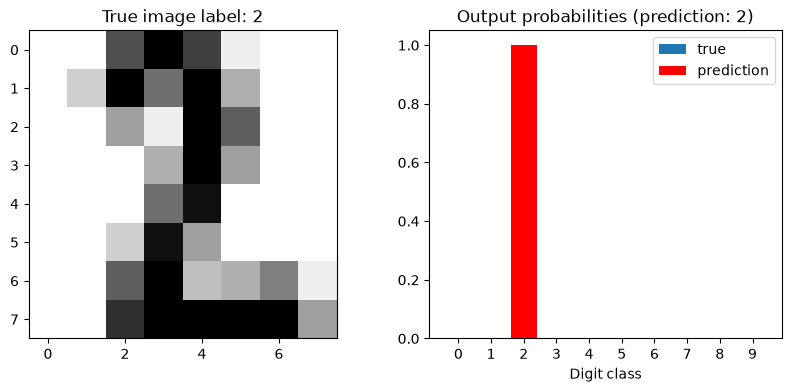

In [20]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

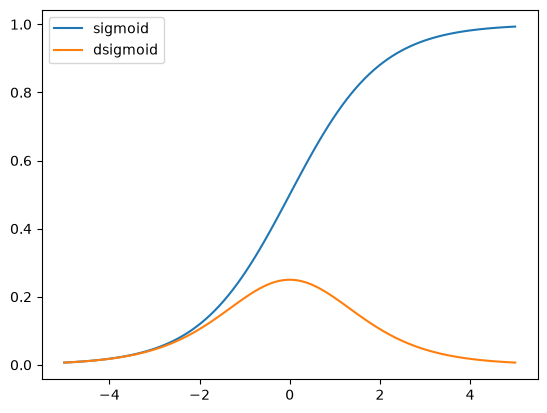

In [21]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    # Sigmoid squashes any real number into the range (0, 1).
    return 1 / (1 + np.exp(-X))


def dsigmoid(X):
    # Derivative of the sigmoid, evaluated at the PRE-activation input X.
    # Handy identity: d/dX sigmoid(X) = sigmoid(X) * (1 - sigmoid(X)),
    # so we can just reuse the sigmoid function we wrote above.
    s = sigmoid(X)
    return s * (1 - s)


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [22]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights (the "pre-activation").
        # Shape: (batch_size, hidden_size). We keep Z_h on the object because
        # backprop needs this PRE-activation value to evaluate dsigmoid later.
        self.Z_h = np.dot(X, self.W_h) + self.b_h

        # Apply the sigmoid activation function to get the hidden layer's output H.
        # We also store H because the output-layer weight gradient depends on the
        # hidden layer's OUTPUT (not its pre-activation) - see grad_loss below.
        self.H = sigmoid(self.Z_h)
        return self.H

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights.
        # Shape: (batch_size, output_size). These are the raw scores ("logits").
        self.Z_o = np.dot(H, self.W_o) + self.b_o

        # Turn the logits into a probability distribution over the classes with softmax.
        # NOTE: we use softmax here (not sigmoid) so the outputs sum to 1 and pair
        # cleanly with the negative-log-likelihood loss. This pairing is exactly what
        # makes error_o = (y_pred - y_true) the correct output gradient in grad_loss.
        return softmax(self.Z_o)

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return Y

    def loss(self, X, y):
        y = y.astype(int)
        # One-hot encode the true labels, run the forward pass, then measure the
        # average negative log likelihood per sample (nll sums, so we divide by batch size).
        y_onehot = one_hot(self.output_size, y)
        return nll(y_onehot, self.forward(X)) / X.shape[0]

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer.
        # Because we combined softmax + NLL, the gradient w.r.t. the output logits
        # simplifies to just (prediction - truth).
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o.
        # The output-layer weights connect the hidden OUTPUT H to the logits,
        # so the gradient uses H (self.H), not the pre-activation Z_h.
        grad_W_o = np.dot(self.H.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Propagate the error back to the hidden layer (this is the chain rule):
        # push error_o through W_o, then multiply by the local slope dsigmoid(Z_h).
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.Z_h)

        # Compute the gradient of the loss with respect to W_h and b_h.
        # The hidden-layer weights connect the input X to Z_h, so this uses X.
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [23]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [24]:
model.loss(X_train, y_train)

np.float64(2.3042566326989817)

In [25]:
model.accuracy(X_train, y_train)

np.float64(0.08382449246889326)

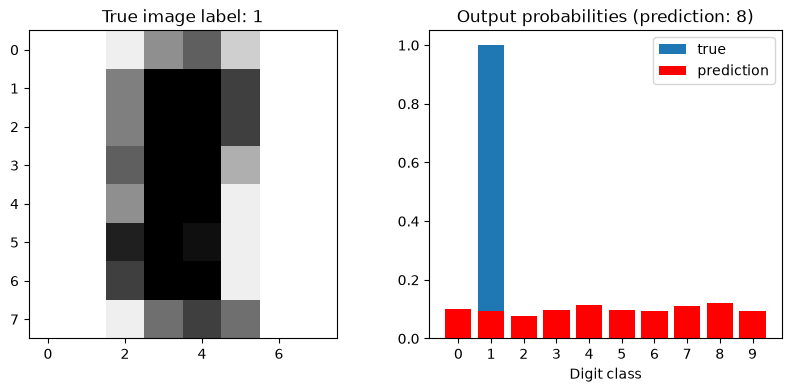

In [26]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [27]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 2.30426, train acc: 0.084, test acc: 0.085
Epoch #1, train loss: 2.18839, train acc: 0.349, test acc: 0.344
Epoch #2, train loss: 2.08163, train acc: 0.432, test acc: 0.433
Epoch #3, train loss: 1.97381, train acc: 0.495, test acc: 0.467
Epoch #4, train loss: 1.86223, train acc: 0.528, test acc: 0.485
Epoch #5, train loss: 1.75095, train acc: 0.599, test acc: 0.552
Epoch #6, train loss: 1.64240, train acc: 0.647, test acc: 0.596
Epoch #7, train loss: 1.53850, train acc: 0.687, test acc: 0.637
Epoch #8, train loss: 1.44118, train acc: 0.737, test acc: 0.681
Epoch #9, train loss: 1.35079, train acc: 0.785, test acc: 0.722
Epoch #10, train loss: 1.26722, train acc: 0.824, test acc: 0.785
Epoch #11, train loss: 1.19016, train acc: 0.860, test acc: 0.833
Epoch #12, train loss: 1.11932, train acc: 0.876, test acc: 0.859
Epoch #13, train loss: 1.05409, train acc: 0.889, test acc: 0.878
Epoch #14, train loss: 0.99384, train acc: 0.902, test acc: 0.900
Epoch #15, train 

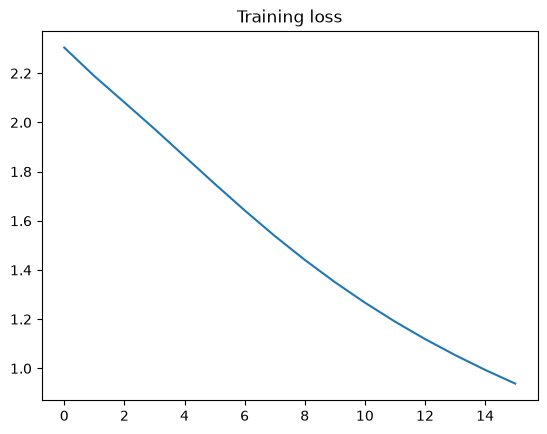

In [28]:
plt.plot(losses)
plt.title("Training loss");

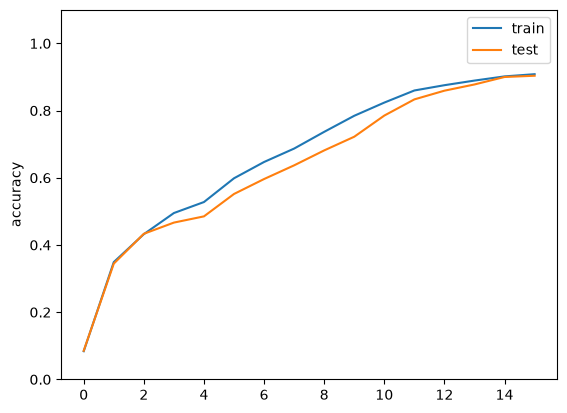

In [29]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

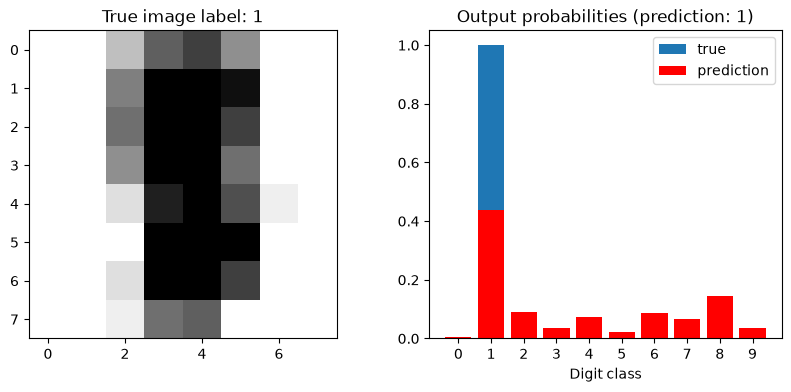

In [30]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Worst test sample indices: [107  99 249   9 121]
Prob assigned to true class: [0.033  0.0815 0.0943 0.1061 0.1156]
Predicted / True: [(np.int64(3), np.int32(5)), (np.int64(1), np.int32(4)), (np.int64(8), np.int32(9)), (np.int64(3), np.int32(5)), (np.int64(8), np.int32(5))]


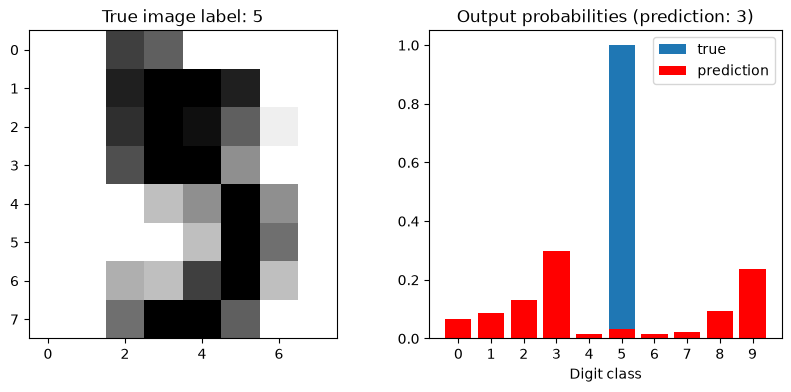

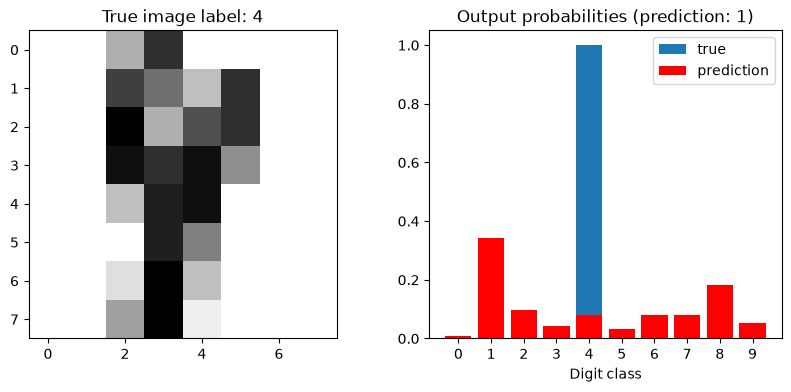

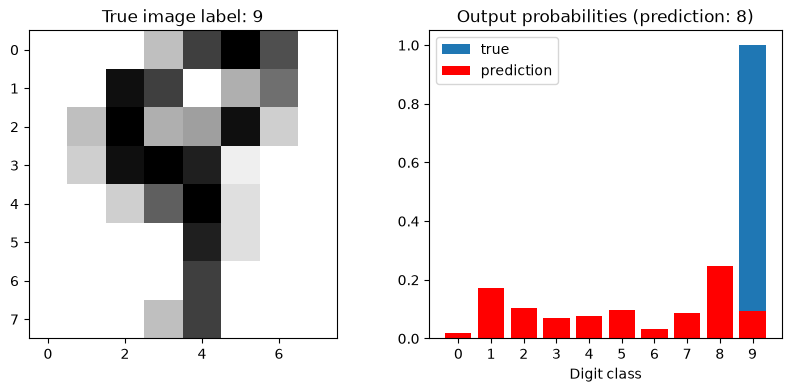

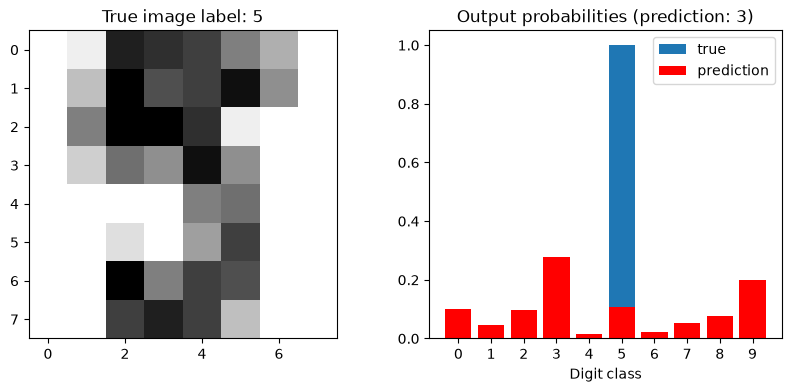

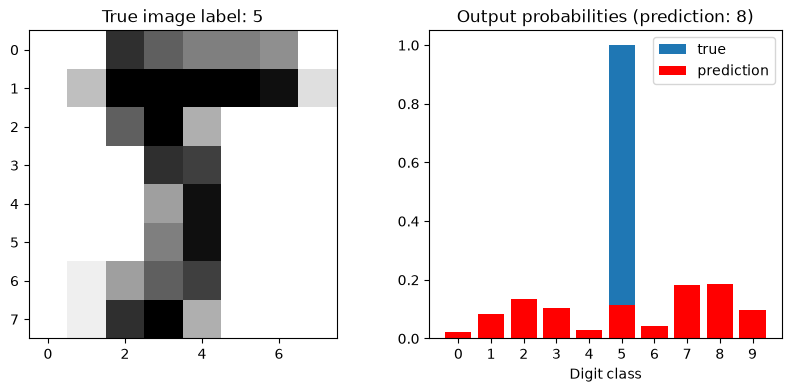

In [31]:
# Your code here
# Probability the model assigned to EVERY class, for every test sample
probs = model.forward(X_test)

# The probability it assigned to the *correct* class for each sample.
# Fancy-indexing: for row i, pick column y_test[i].
true_class_probs = probs[np.arange(len(y_test)), y_test]

# "Worst" predictions = the ones where the model gave the true class the
# lowest probability (i.e. it was most wrong / least confident about the truth).
worst_indices = np.argsort(true_class_probs)[:5]

print("Worst test sample indices:", worst_indices)
print("Prob assigned to true class:", np.round(true_class_probs[worst_indices], 4))
print("Predicted / True:", list(zip(np.argmax(probs[worst_indices], axis=1),
                                    y_test[worst_indices])))

# Visualize each of the worst cases
for idx in worst_indices:
    plot_prediction(model, sample_idx=int(idx))

# Observation: the model gives the true class only ~5-10% probability on these,
# and its mistakes are "sensible" confusions between visually similar digits
# (e.g. 5<->3, 4<->7, 7<->4). At 8x8 resolution these strokes really are
# ambiguous - a human would hesitate on the same images. That the errors cluster
# on genuinely hard samples (rather than being random) suggests the model has
# learned real structure and is near the ceiling of what this low-res data allows.

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [32]:
# Your code here

# --- (i) Sweep learning rate and hidden-layer size on the 1-hidden-layer net ---
def train_nn(hidden_size, lr, epochs=10):
    net = NeuralNet(n_features, hidden_size, n_classes)
    for _ in range(epochs):
        for x, y in zip(X_train, y_train):
            net.train(x, y, lr)
    return net.accuracy(X_test, y_test)

print("1 hidden layer (10 epochs):")
for hidden_size in [10, 32, 64]:
    for lr in [0.001, 0.01]:
        acc = train_nn(hidden_size, lr)
        print(f"  hidden={hidden_size:3d}  lr={lr:<6} -> test acc {acc:.3f}")


# --- (ii) Support a SECOND hidden layer ---
# Same idea as NeuralNet, just one more sigmoid layer. Backprop = apply the chain
# rule one extra time: push the error back through W_o, then W2, then W1, each
# time multiplying by the local sigmoid slope dsigmoid(pre-activation).
class NeuralNet2():
    """MLP with 2 hidden sigmoid layers and a softmax output."""

    def __init__(self, input_size, hidden1, hidden2, output_size):
        u = lambda a, b: np.random.uniform(size=(a, b), high=0.1, low=-0.1)
        self.W1 = u(input_size, hidden1); self.b1 = np.random.uniform(size=hidden1, high=0.1, low=-0.1)
        self.W2 = u(hidden1, hidden2);    self.b2 = np.random.uniform(size=hidden2, high=0.1, low=-0.1)
        self.Wo = u(hidden2, output_size); self.bo = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        self.output_size = output_size

    def forward(self, X):
        if X.ndim == 1:
            X = X[np.newaxis, :]
        self.X = X
        self.Z1 = X @ self.W1 + self.b1;       self.H1 = sigmoid(self.Z1)   # hidden 1
        self.Z2 = self.H1 @ self.W2 + self.b2; self.H2 = sigmoid(self.Z2)   # hidden 2
        self.Zo = self.H2 @ self.Wo + self.bo                               # logits
        return softmax(self.Zo)

    def train(self, x, y, learning_rate):
        y_pred = self.forward(x)
        y_true = one_hot(self.output_size, np.array([y]))

        error_o = y_pred - y_true                              # softmax+NLL shortcut
        grad_Wo = self.H2.T @ error_o; grad_bo = error_o.sum(0)

        error_2 = (error_o @ self.Wo.T) * dsigmoid(self.Z2)    # chain rule -> hidden 2
        grad_W2 = self.H1.T @ error_2; grad_b2 = error_2.sum(0)

        error_1 = (error_2 @ self.W2.T) * dsigmoid(self.Z1)    # chain rule -> hidden 1
        grad_W1 = self.X.T @ error_1;  grad_b1 = error_1.sum(0)

        self.Wo -= learning_rate * grad_Wo; self.bo -= learning_rate * grad_bo
        self.W2 -= learning_rate * grad_W2; self.b2 -= learning_rate * grad_b2
        self.W1 -= learning_rate * grad_W1; self.b1 -= learning_rate * grad_b1

    def accuracy(self, X, y):
        return np.mean(np.argmax(self.forward(X), axis=1) == y)

print("\n2 hidden layers (64, 32), 15 epochs:")
for lr in [0.001, 0.01]:
    net2 = NeuralNet2(n_features, 64, 32, n_classes)
    for _ in range(15):
        for x, y in zip(X_train, y_train):
            net2.train(x, y, lr)
    print(f"  lr={lr:<6} -> test acc {net2.accuracy(X_test, y_test):.3f}")

# Observation:
# - Hidden size matters a lot: hidden=10 underfits (~75-89%), while hidden=64
#   gives the model enough capacity to reach ~97%. Best single-layer result here:
#   hidden=64, lr=0.01 -> ~0.97.
# - Learning rate matters too: at every size, lr=0.01 beats lr=0.001 for a fixed
#   epoch budget - the smaller rate just hasn't converged yet in 10-15 epochs.
# - The second hidden layer does NOT beat the best single-layer net (~0.97 vs
#   ~0.97). Deeper is not automatically better on this small, simple dataset.
#   It is also more sensitive: at lr=0.001 the 2-layer net collapses to ~0.47
#   because gradients shrink as they pass back through the extra sigmoid layer
#   (vanishing gradients), so it needs the larger lr=0.01 just to train at all.
# - Takeaway: for these 8x8 digits, a single wide hidden layer (~64) with a
#   reasonable learning rate is the sweet spot; ~97% test accuracy is the ceiling.

1 hidden layer (10 epochs):
  hidden= 10  lr=0.001  -> test acc 0.822
  hidden= 10  lr=0.01   -> test acc 0.885
  hidden= 32  lr=0.001  -> test acc 0.926
  hidden= 32  lr=0.01   -> test acc 0.948
  hidden= 64  lr=0.001  -> test acc 0.948
  hidden= 64  lr=0.01   -> test acc 0.963

2 hidden layers (64, 32), 15 epochs:
  lr=0.001  -> test acc 0.444
  lr=0.01   -> test acc 0.959
